Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1, Batch 0, Loss: 1.1651
Epoch 1, Batch 100, Loss: 0.5852
Epoch 1, Batch 200, Loss: 0.2145
Epoch 1 Complete
Train Loss: 0.5171
Validation Loss: 0.3684
Epoch 2, Batch 0, Loss: 0.4981
Epoch 2, Batch 100, Loss: 0.2823
Epoch 2, Batch 200, Loss: 0.2329
Epoch 2 Complete
Train Loss: 0.2454
Validation Loss: 0.3661
Validation Accuracy: 0.88
              precision    recall  f1-score   support

    negative       0.86      0.87      0.87       334
     neutral       0.88      0.88      0.88       480
    positive       0.90      0.88      0.89       386

    accuracy                           0.88      1200
   macro avg       0.88      0.88      0.88      1200
weighted avg       0.88      0.88      0.88      1200



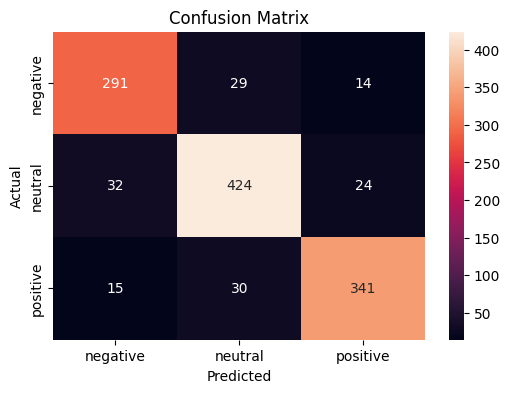

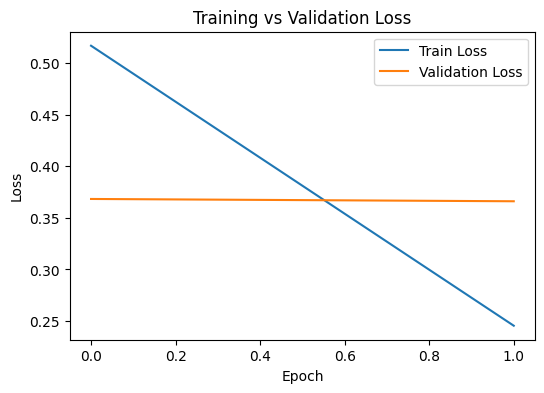

`sdpa` attention does not support `output_attentions=True`. Please set your attention to `eager` if you want any of these features.


TypeError: 'NoneType' object is not subscriptable

In [2]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/kaggle/input/datasets/disha808/tweets-data/Tweets.csv'
df = pd.read_csv(file_path)

df = df[['selected_text', 'sentiment']].dropna()
df['selected_text'] = df['selected_text'].astype(str)
df = df.sample(6000, random_state=42)

le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'])

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['selected_text'].tolist(),
    df['sentiment'].tolist(),
    test_size=0.2,
    random_state=42
)

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=64)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=64)

class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, train_labels)
val_dataset = SentimentDataset(val_encodings, val_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)
optimizer = AdamW(model.parameters(), lr=2e-5)

train_losses = []
val_losses = []

for epoch in range(2):
    model.train()
    total_train_loss = 0

    for i, batch in enumerate(train_loader):
        optimizer.zero_grad()

        input_ids = batch['input_ids']
        attention_mask = batch['attention_mask']
        labels = batch['labels']

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        loss = outputs.loss
        total_train_loss += loss.item()

        loss.backward()
        optimizer.step()

        if i % 100 == 0:
            print(f'Epoch {epoch+1}, Batch {i}, Loss: {loss.item():.4f}')

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0
    preds = []
    true_vals = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids']
            attention_mask = batch['attention_mask']
            labels = batch['labels']

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

            loss = outputs.loss
            logits = outputs.logits

            total_val_loss += loss.item()
            preds.extend(torch.argmax(logits, dim=1).numpy())
            true_vals.extend(labels.numpy())

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f'Epoch {epoch+1} Complete')
    print(f'Train Loss: {avg_train_loss:.4f}')
    print(f'Validation Loss: {avg_val_loss:.4f}')

acc = accuracy_score(true_vals, preds)
print("Validation Accuracy:", acc)
print(classification_report(true_vals, preds, target_names=le.classes_))

cm = confusion_matrix(true_vals, preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

sample_text = str(val_texts[0])
inputs = tokenizer(sample_text, return_tensors='pt', truncation=True, padding=True, max_length=32)

with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)

attentions = outputs.attentions[-1][0][0].numpy()
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

plt.figure(figsize=(10,8))
sns.heatmap(attentions[:len(tokens), :len(tokens)], xticklabels=tokens, yticklabels=tokens)
plt.title("BERT Attention Heatmap")
plt.show()

custom_text = "I really enjoyed this movie"
enc = tokenizer(custom_text, return_tensors='pt', truncation=True, padding=True, max_length=64)

with torch.no_grad():
    out = model(**enc)

pred = torch.argmax(out.logits, dim=1).item()
print("Predicted Sentiment:", le.inverse_transform([pred])[0])